# `sc_inj` Impact-T compare Impact old and new solrf

In [1]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from impact import Impact
from distgen import Generator
from pmd_beamphysics import ParticleGroup, single_particle
import numpy as np

# Distgen particles

In [4]:
DISTGEN_IN = '$LCLS_LATTICE/distgen/models/sc_inj/v0/distgen.yaml'

G = Generator(DISTGEN_IN)
G['n_particle'] = 100_000

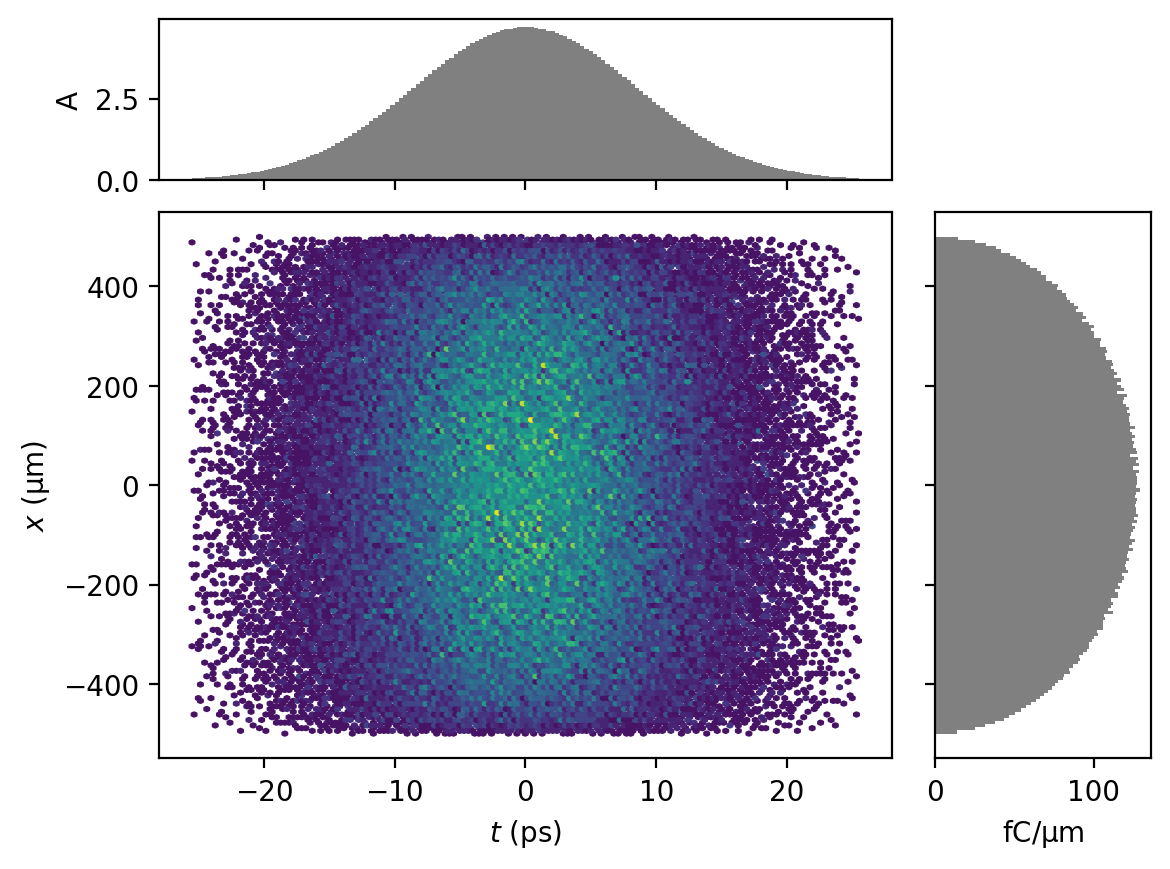

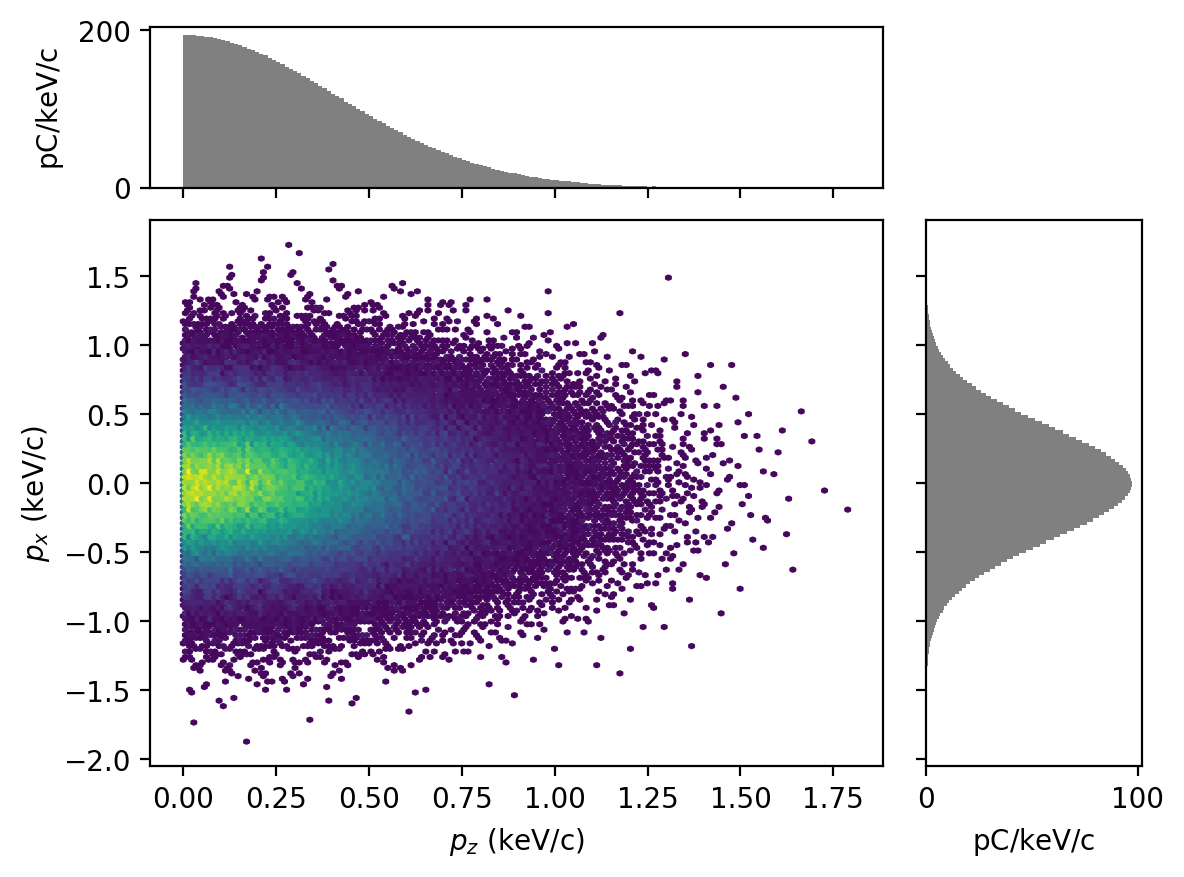

In [5]:
# Make the particles
G.run()
P0 = G.particles
P0.plot('t', 'x')
P0.plot('pz', 'px')

# Impact

In [6]:
ZSTOP = 14

def run1(style):

    if style == 'fourier':
        Impact.command_env     = 'IMPACTT_BIN'
        Impact.command_mpi_env = 'IMPACTT_MPI_BIN'
        IMPACT_IN = '$LCLS_LATTICE/impact/models/sc_inj/v1/ImpactT.in'
    elif style == 'derivatives':
        Impact.command_env     = 'NEW_IMPACTT_BIN'
        Impact.command_mpi_env = 'NEW_IMPACTT_MPI_BIN'
        IMPACT_IN = '$LCLS_LATTICE/impact/models/sc_inj/v1new/ImpactT.in'
    else:
        raise
            
    
    
    I = Impact(IMPACT_IN, initial_particles=P0)    
    I.stop = ZSTOP
    I.total_charge = 100e-12
    #I.verbose=True
    I.numprocs = 8
    I.run()
    return I


In [7]:
%%time
I1 = run1('fourier')

CPU times: user 3.51 s, sys: 883 ms, total: 4.39 s
Wall time: 9min 35s


In [8]:
%%time
I2 = run1('derivatives')

CPU times: user 3.44 s, sys: 828 ms, total: 4.27 s
Wall time: 5min 2s


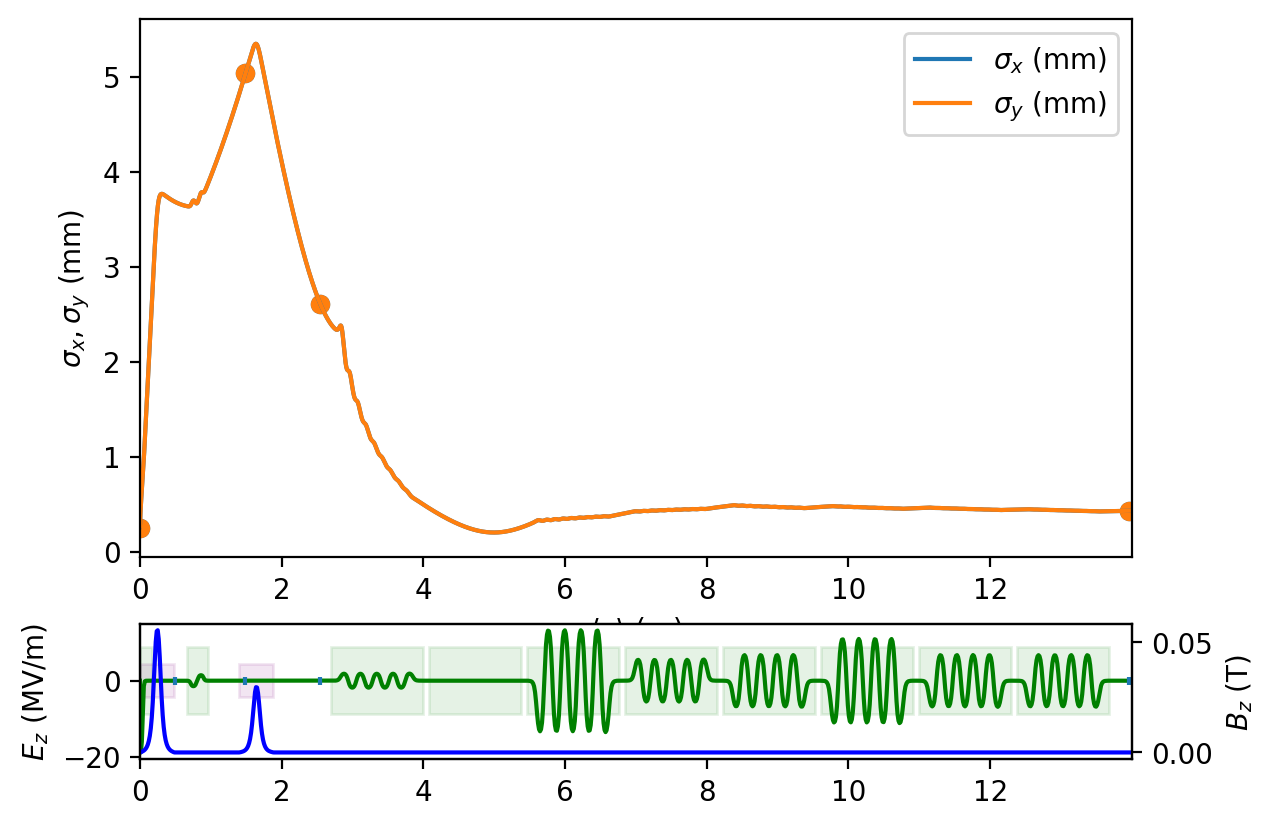

In [9]:
I1.plot()

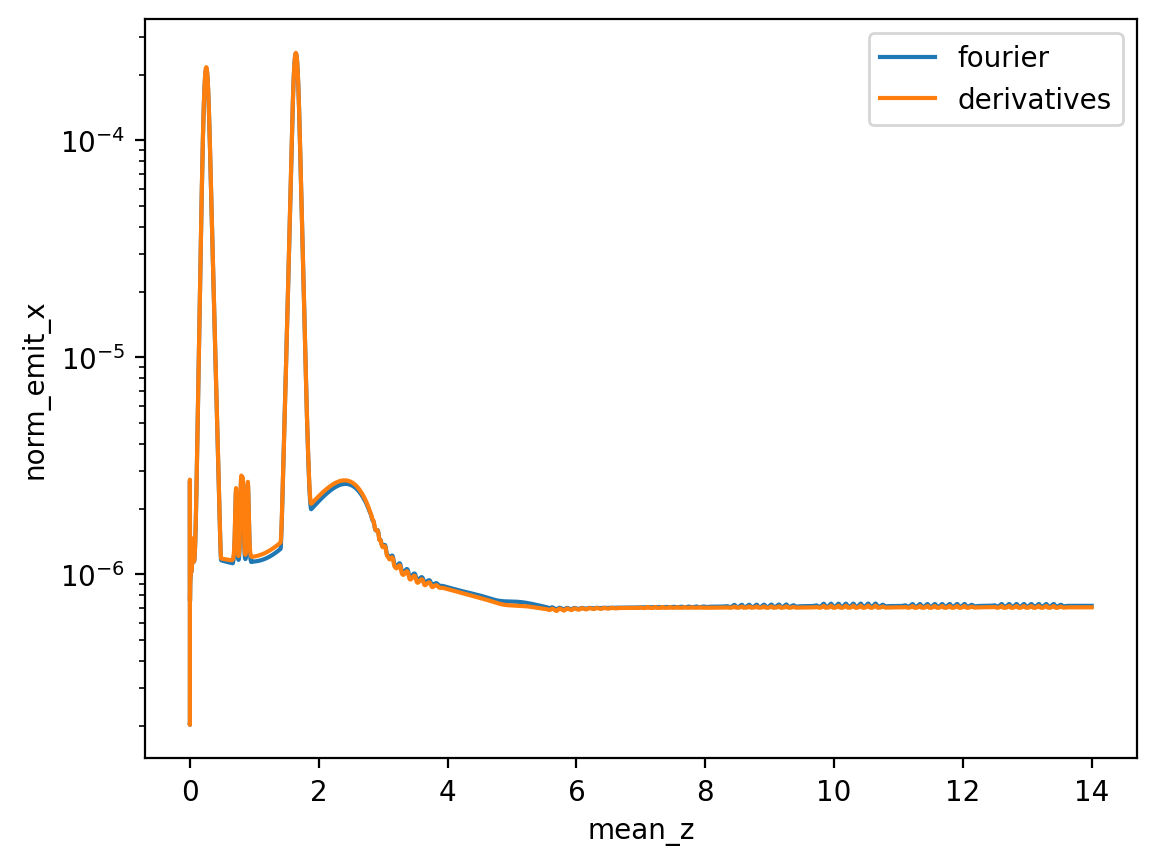

In [10]:
def compare(ykey='mean_x', xkey='mean_z'):
    
    
    fig, ax = plt.subplots()
    for name, I in ( ('fourier', I1), ('derivatives', I2)):
        x = I.stat(xkey)
        y = I.stat(ykey)
        ax.plot(x, y, label=name)
        
    plt.legend()
    ax.set_xlabel(xkey)
    ax.set_ylabel(ykey)
        

        
compare('norm_emit_x')
plt.yscale('log')

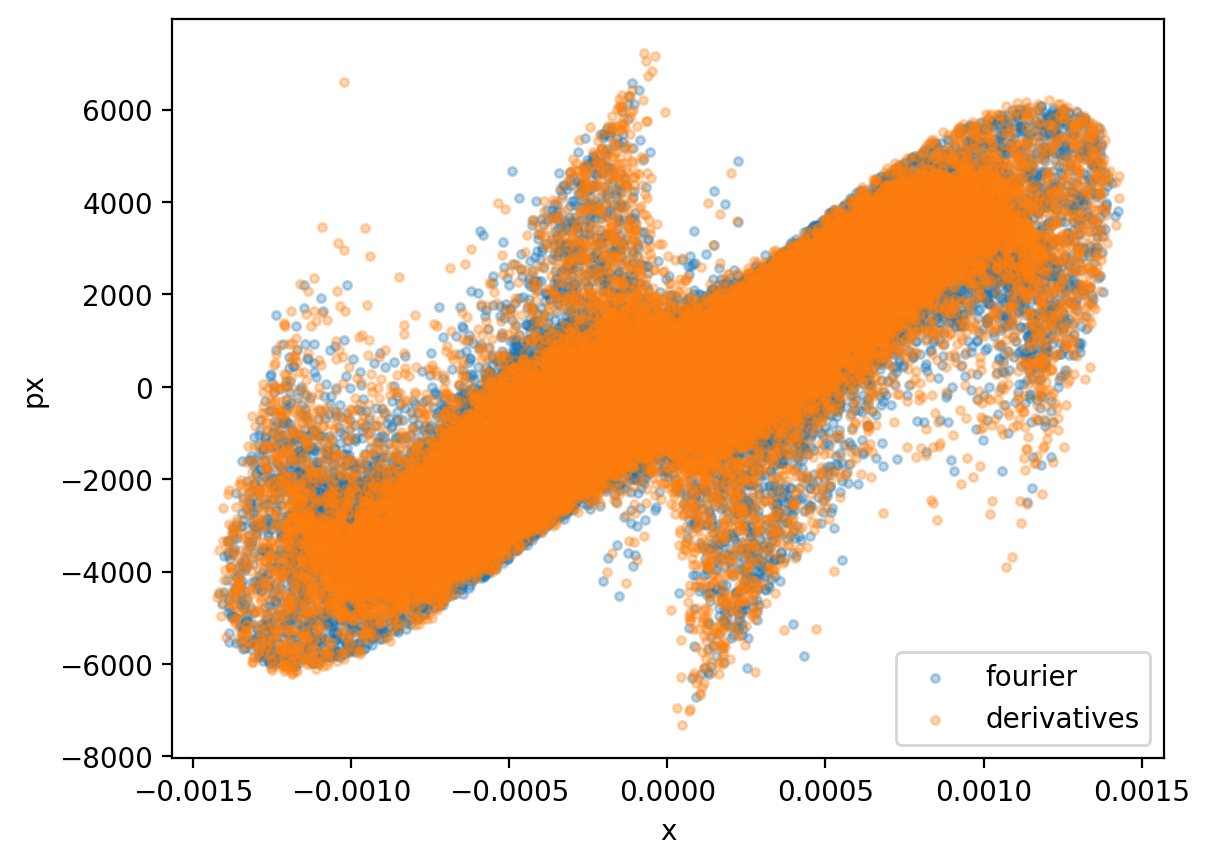

In [11]:
P1 = I1.particles['final_particles']
P2 = I2.particles['final_particles']


def pcompare( xkey='x', ykey='y', skip=1):

    fig, ax = plt.subplots()
    for name, I in ( ('fourier', I1), ('derivatives', I2)):
        x = I.particles['final_particles'][xkey][::skip]
        y = I.particles['final_particles'][ykey][::skip]
        ax.scatter(x, y, label=name, marker='.', alpha=0.3)
        
    plt.legend()
    ax.set_xlabel(xkey)
    ax.set_ylabel(ykey)
pcompare('x', 'px')

In [12]:
P1.twiss(), P2.twiss()

({'alpha_x': -1.752586440152963,
  'beta_x': 50.556500897909615,
  'gamma_x': 0.08053483049449699,
  'emit_x': 3.6600708631788674e-09,
  'eta_x': -0.00012763001737934858,
  'etap_x': -8.023972617840978e-06,
  'norm_emit_x': 7.162055255902139e-07},
 {'alpha_x': -1.7896692858207826,
  'beta_x': 51.16509081295833,
  'gamma_x': 0.08214421367831948,
  'emit_x': 3.6030984368111478e-09,
  'eta_x': -8.528942638731867e-05,
  'etap_x': -7.120039268108058e-06,
  'norm_emit_x': 7.05045348955426e-07})

(0.0, 2e-06)

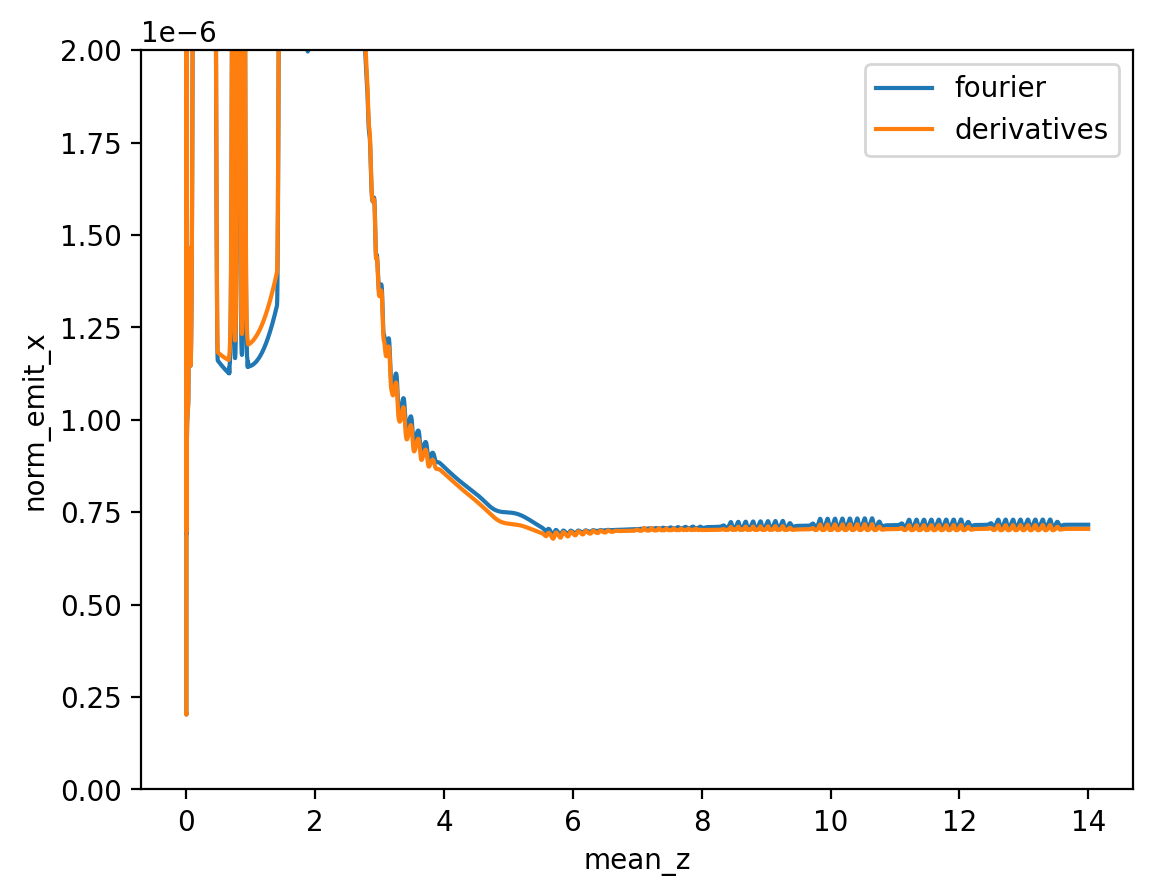

In [13]:
compare('norm_emit_x')
plt.ylim(0, 2e-6)

# Compare with Astra

In [14]:
from astra import Astra
A = Astra.from_archive('$LCLS_LATTICE/astra/models/sc_inj/v1/astra_sc_inj_v1.h5')

In [15]:
if I1.header['Bcurr'] == 0:
    # Re-run without space charge
    A.input['output']['zstop'] = ZSTOP
    A.input['charge']['lspch'] = False
    A.configure()
    #A.verbose=True
    A.initial_particles = P0
    A.run()

In [16]:
A.particles[-1]['norm_emit_x']

6.413844917041914e-07

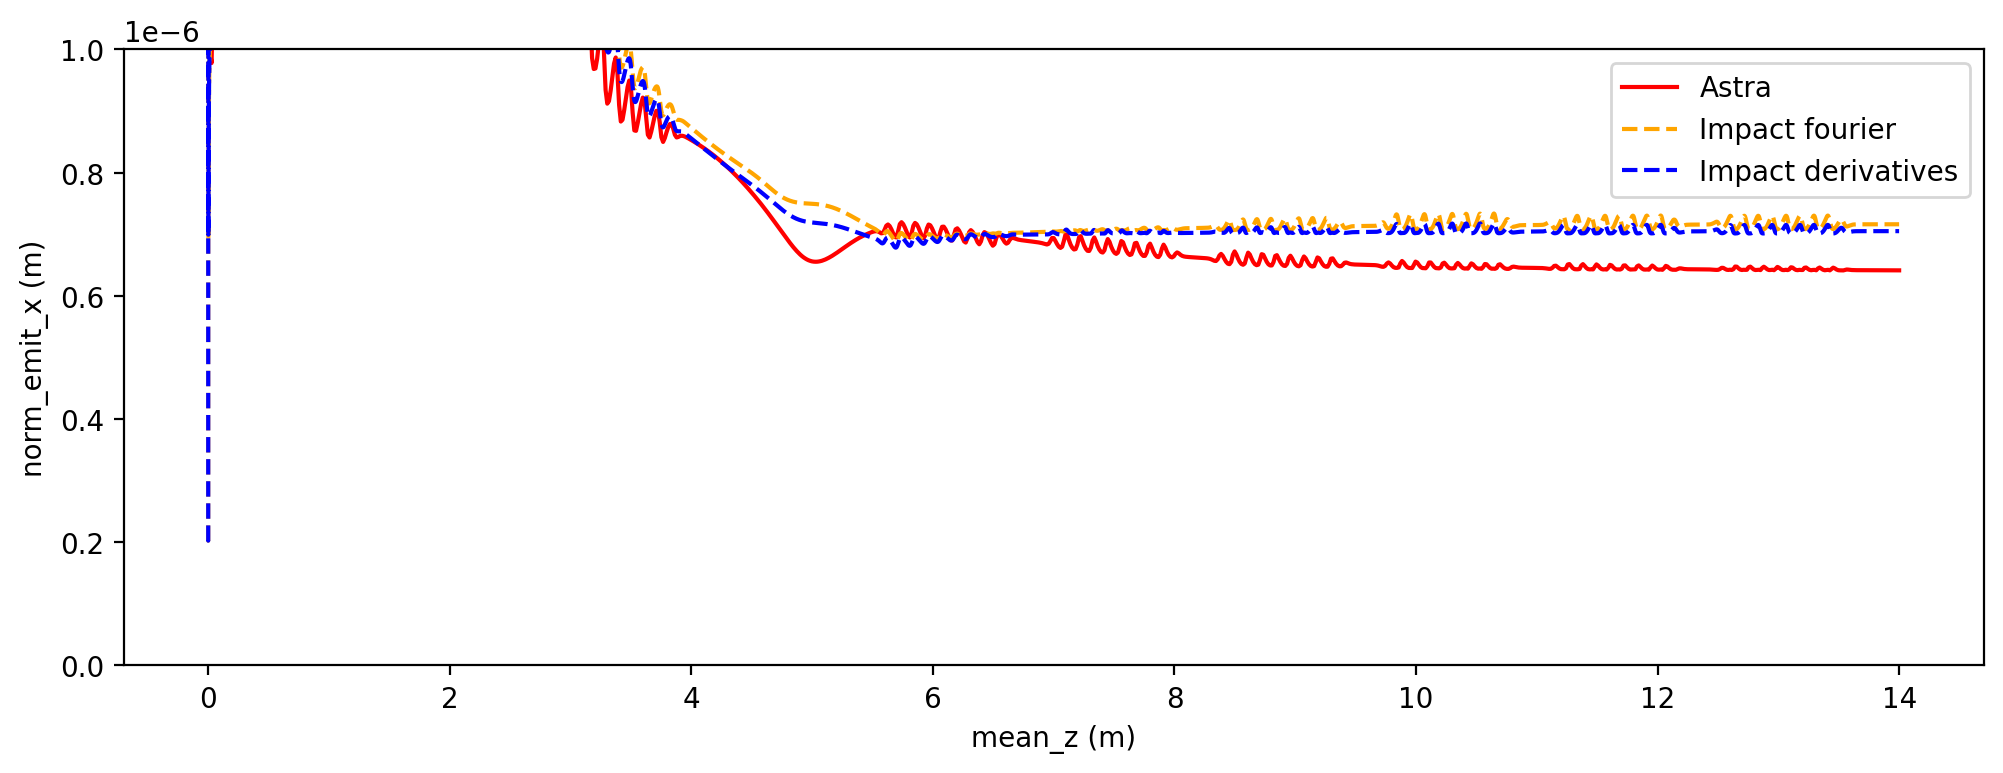

In [17]:
def compare(ykey, xkey = 'mean_z', ylim=None):
    xunits = I1.units(xkey)
    yunits = I1.units(ykey)
    
    fig, ax = plt.subplots(figsize=(12,4))
    
    ax.plot(A.stat(xkey), A.stat(ykey), label='Astra', color='red')
    ax.plot(I1.stat(xkey), I1.stat(ykey), '--', label='Impact fourier', color='orange')
    ax.plot(I2.stat(xkey), I2.stat(ykey), '--', label='Impact derivatives', color='blue')
    ax.set_xlabel(f'{xkey} ({xunits})')
    ax.set_ylabel(f'{ykey} ({yunits})')
    ax.set_ylim(ylim)
    plt.legend()
    
compare('norm_emit_x', ylim=(0, 1e-6))
#plt.yscale('log')
#plt.ylim(6e-9, 4e-6)
#plt.xlim(0, ZSTOP)

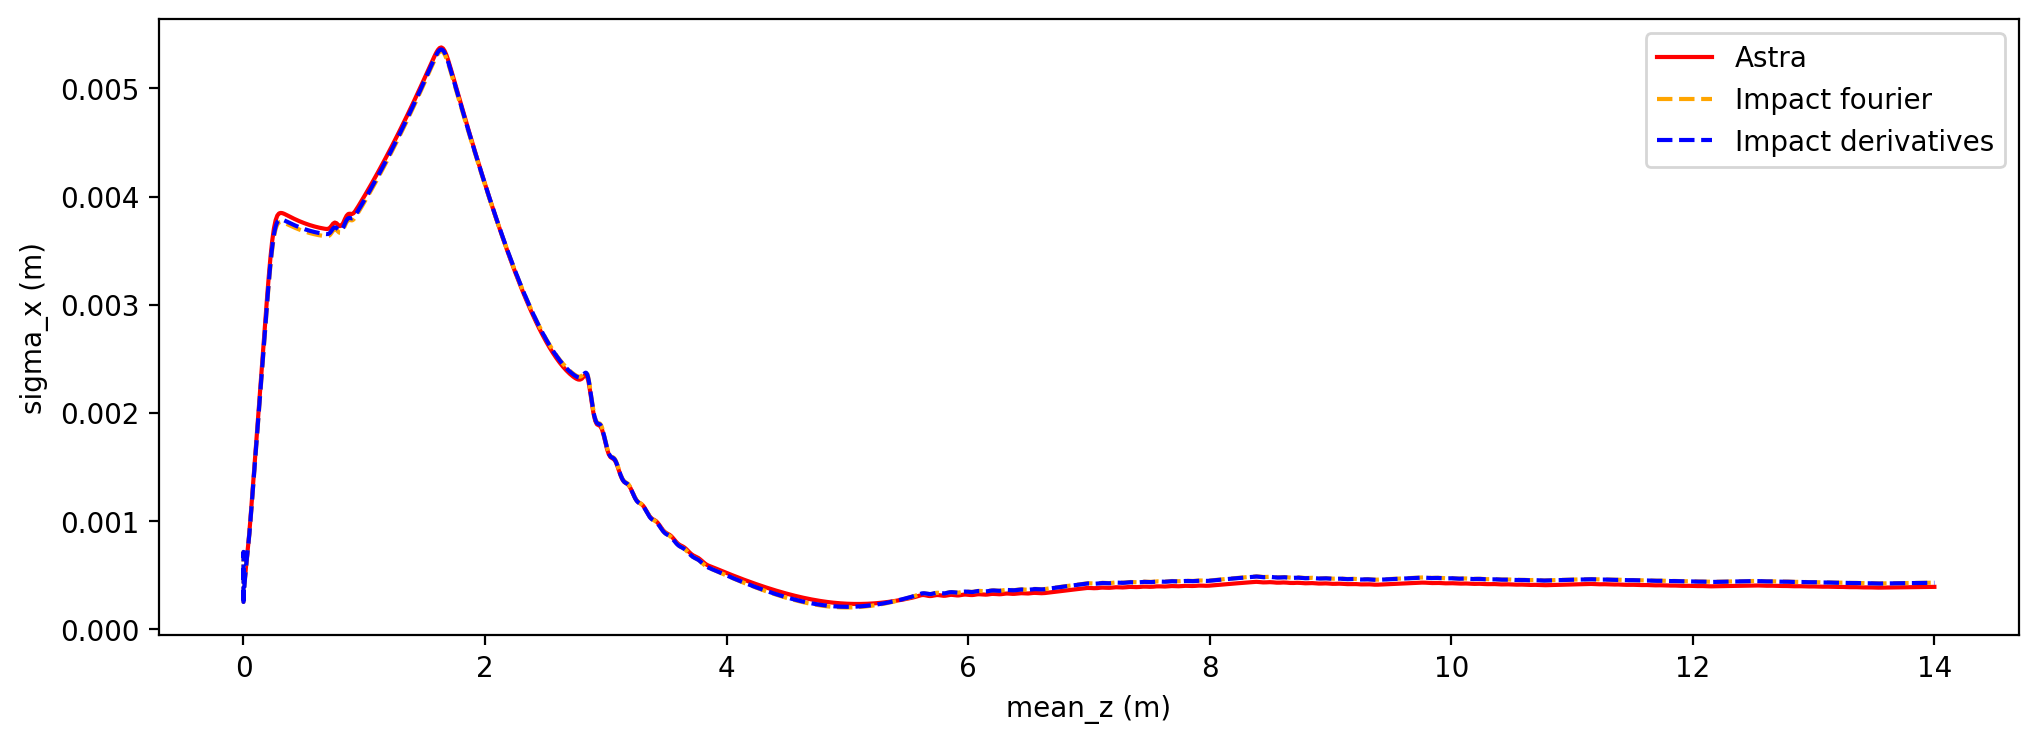

In [18]:
compare('sigma_x')

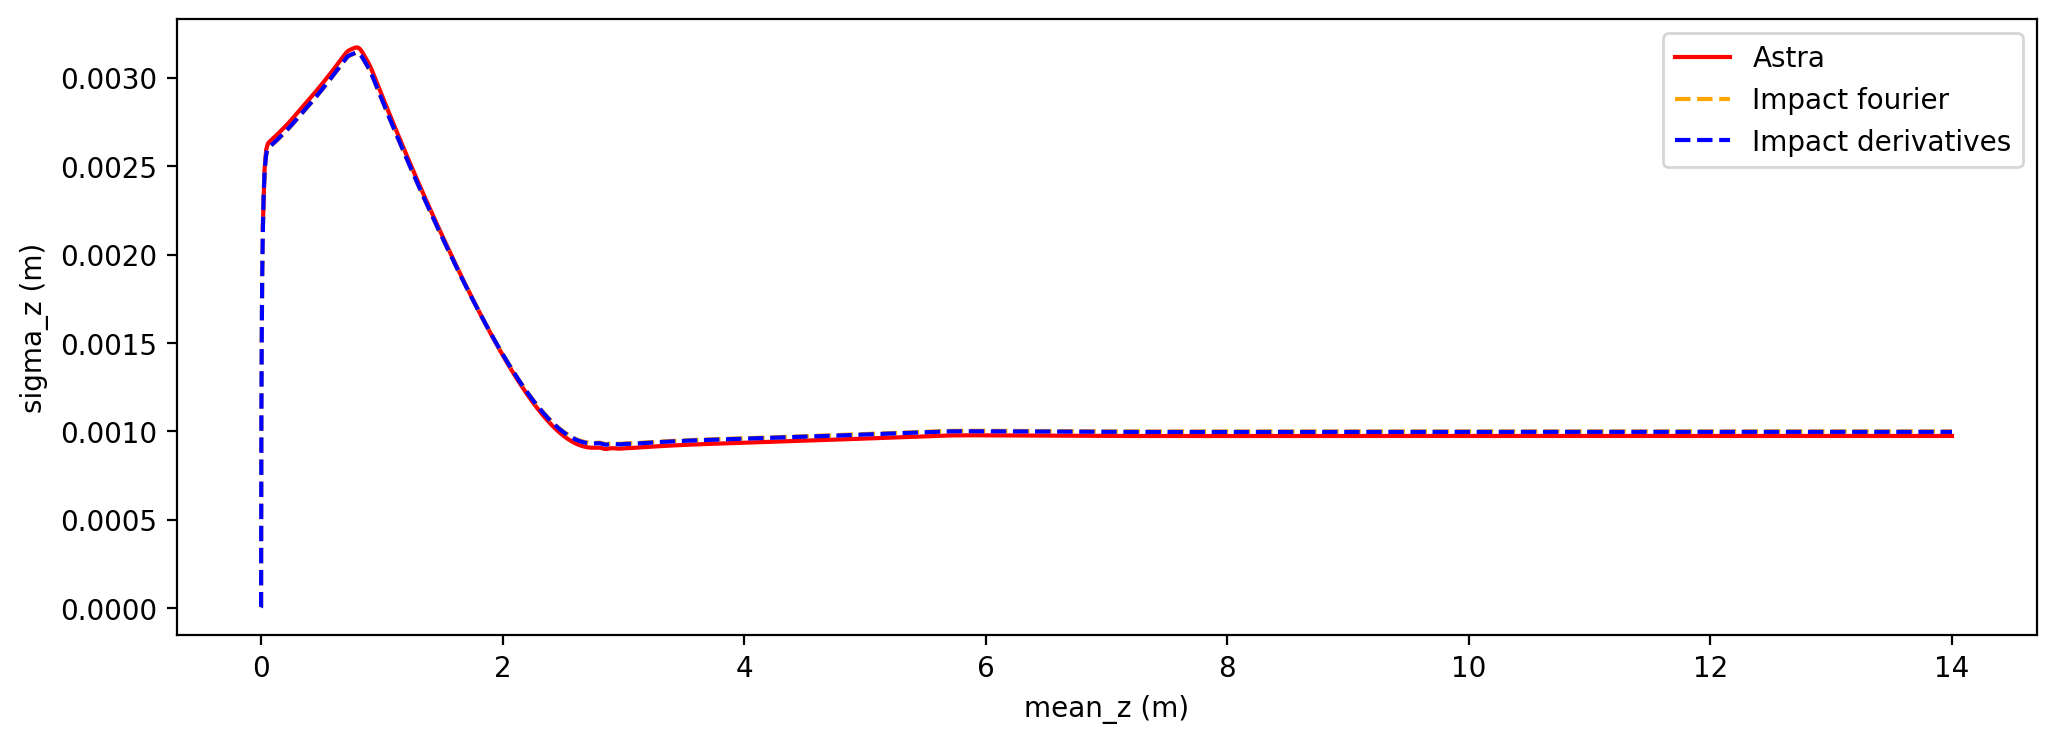

In [19]:
compare('sigma_z')

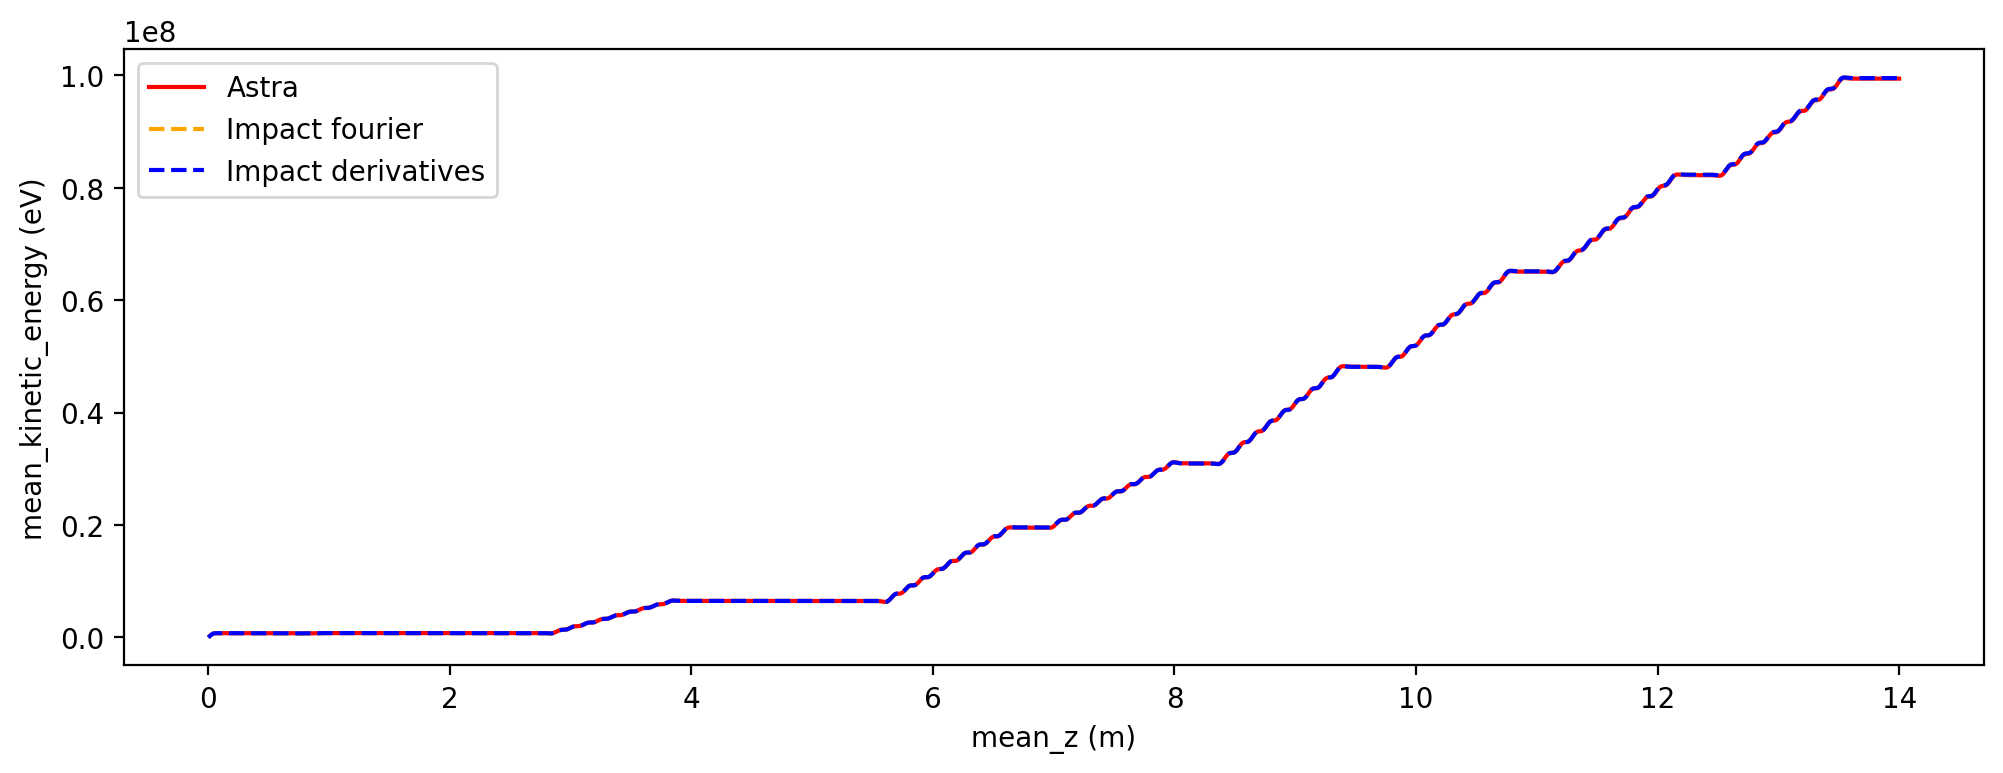

In [20]:
compare('mean_kinetic_energy')

In [21]:
Pa = A.particles[-1].copy()
Pa.drift_to_z(ZSTOP)
Pa.drift_to_t()
Pa['mean_z']

13.999999999984695

In [22]:
Pi = I1.particles['final_particles'].copy()
Pi.drift_to_z(ZSTOP)
Pi.drift_to_t()
Pi['mean_z']

13.999999999996664

In [23]:
Pa['mean_energy']/Pi['mean_energy']

0.9990710341241819

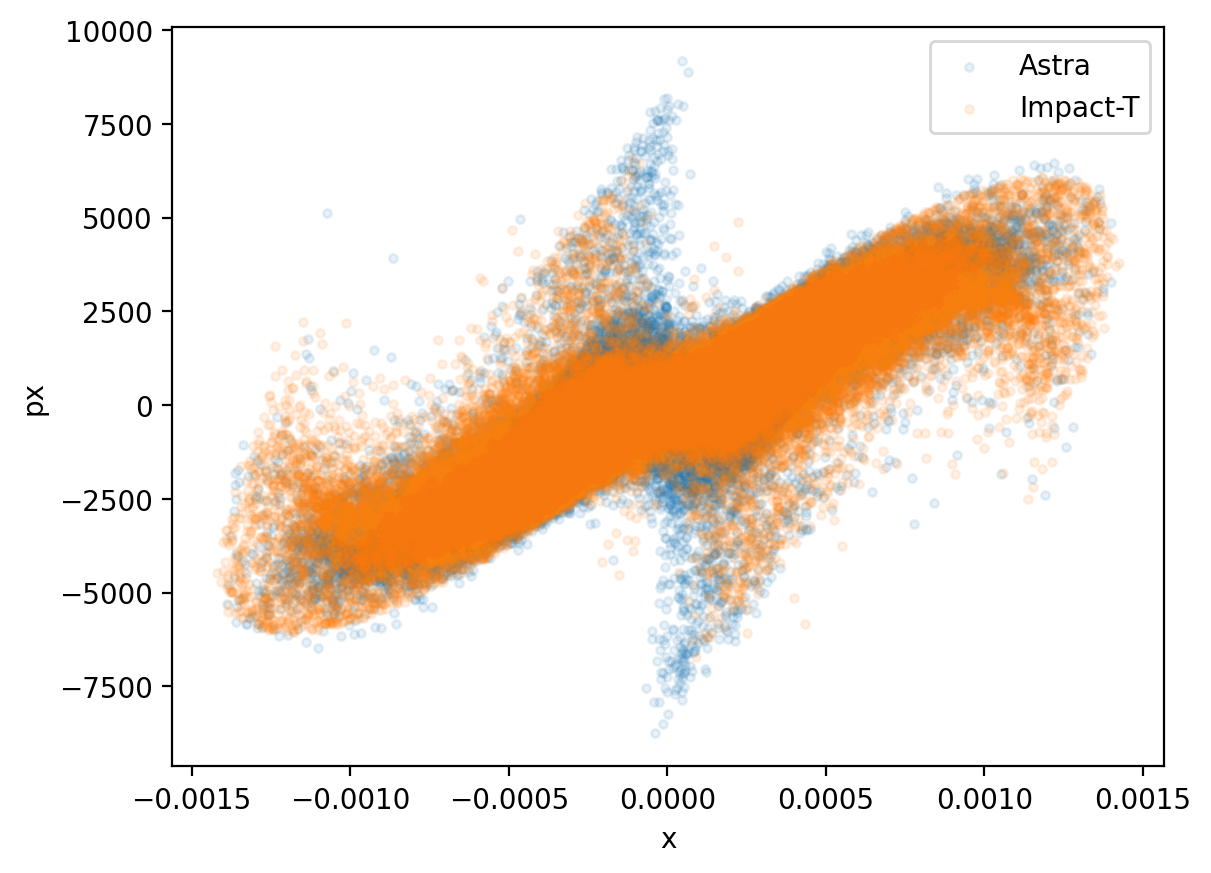

In [24]:
def compare_particles(key1, key2, skip=1):
    for name, P in (("Astra", Pa), ("Impact-T", Pi)):
        plt.scatter(P[key1][::skip], P[key2][::skip], marker='.', alpha=0.1, label=name)
        plt.xlabel(key1)
        plt.ylabel(key2)
    plt.legend()
        
compare_particles('x', 'px')        


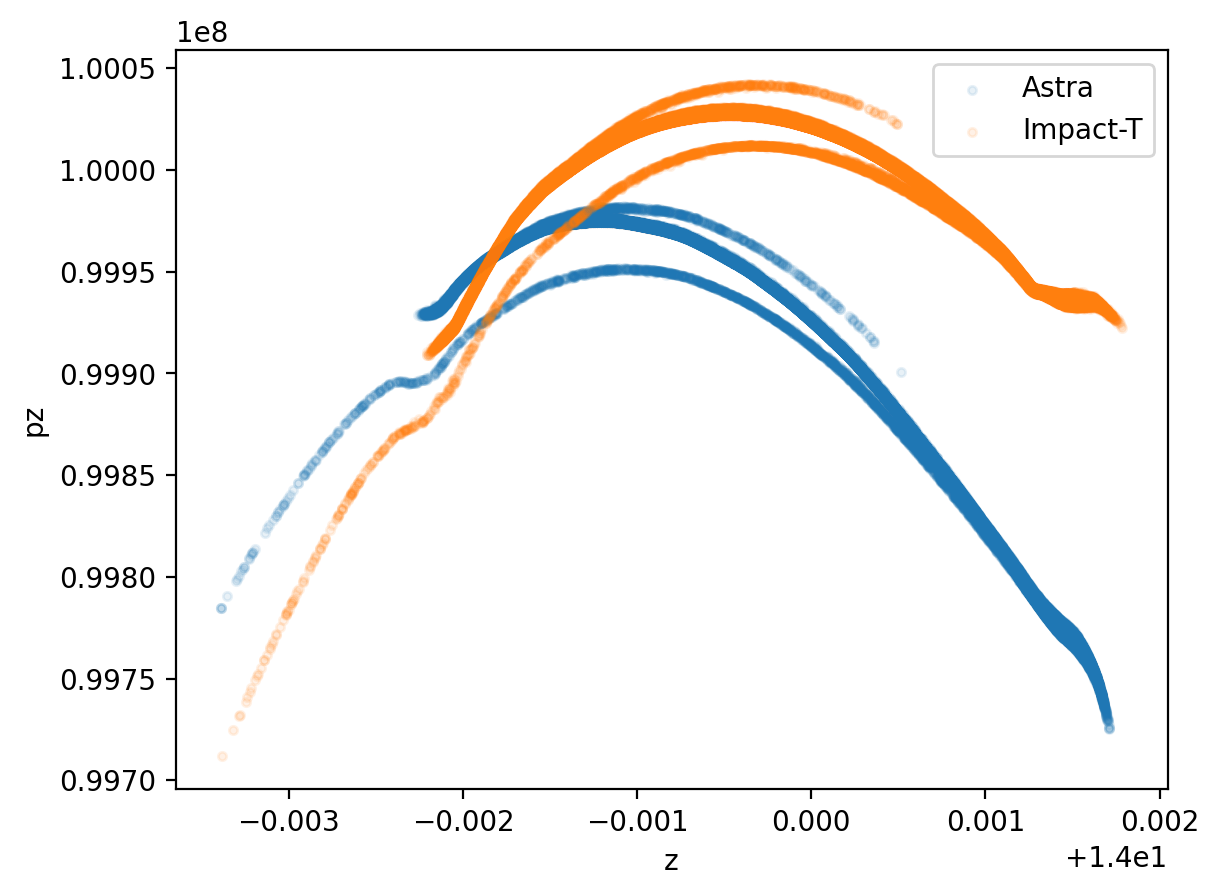

In [25]:
compare_particles('z', 'pz')  

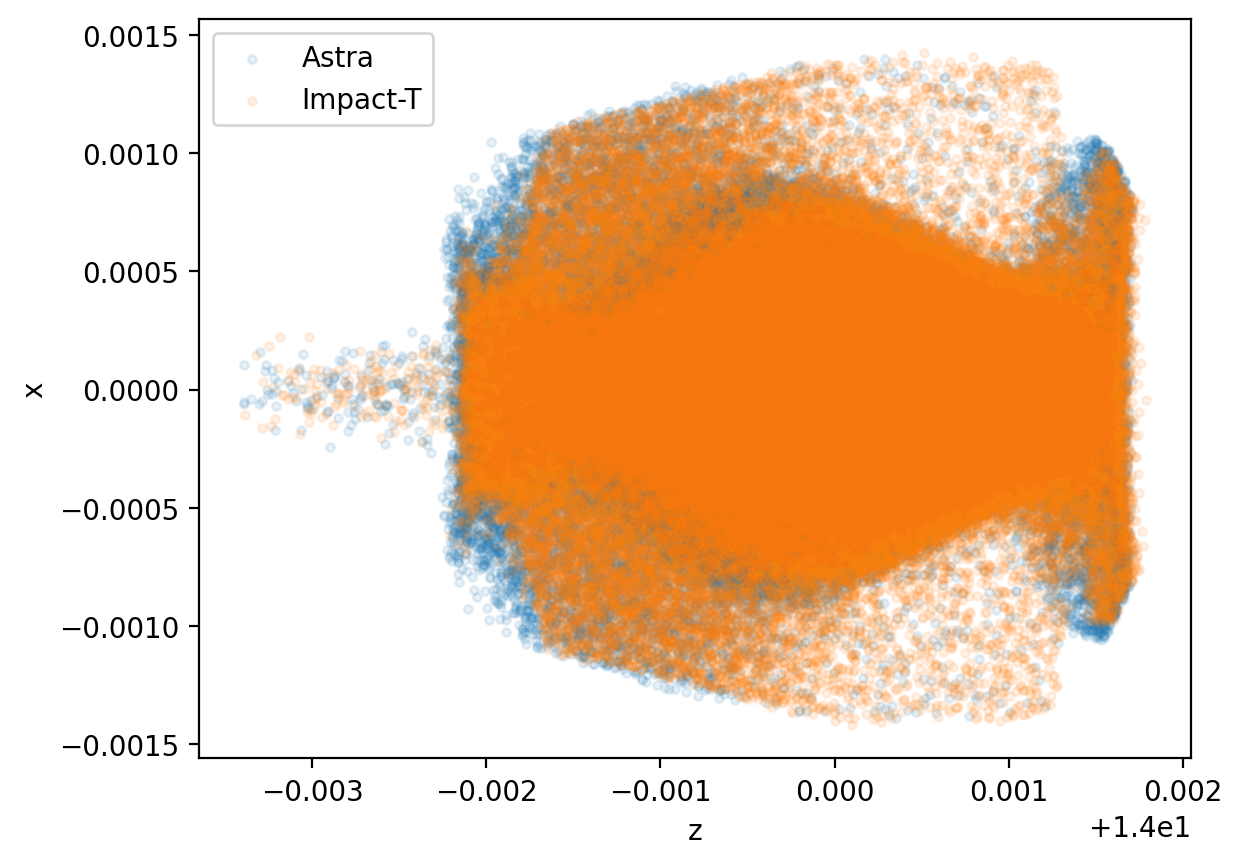

In [26]:
compare_particles('z', 'x')  

# Scan `CAVL011`

In [ ]:
I = I1.copy()
Impact.command_env     = 'IMPACTT_BIN'
Impact.command_mpi_env = 'IMPACTT_MPI_BIN'

In [ ]:
I.plot()

In [ ]:
from concurrent.futures import ProcessPoolExecutor
# Allows processes to work with macOS
from sys import platform 
if platform == 'darwin':
    import multiprocessing as mp
    mp.set_start_method("fork")

In [ ]:
Iref = I.copy()
Pref = I.particles['CM01BEG'].copy()
Iref.output = {}
x0 = Iref.ele['CAVL011']['theta0_deg']
x0

In [ ]:
xlist = np.linspace(x0-5, x0+5, 8)
xlist

In [ ]:
%%time
def set1(x, ele='CAVL011', component='theta0_deg'): 
    I2 = Iref.copy()
    I2.verbose=False
    I2.configure()
    I2.numprocs = 8
    I2.ele[ele][component] = x
    I2.initial_particles = Pref
    I2.run()
    return I2

I2 = set1(274)

In [ ]:
# Best from a scan
xbest = 274
xbest - x0

In [ ]:
0.022222222222222223 * 360 

In [ ]:
I2.plot('norm_emit_x', ylim=(0, 1e-6))

In [ ]:
%%time
with ProcessPoolExecutor(max_workers=8) as executor:
    results1 = list(executor.map(set1, xlist))    

In [ ]:
def compare(ykey, xkey = 'mean_z', ylim=None):
    xunits = I.units(xkey)
    yunits = I.units(ykey)
    
    fig, ax = plt.subplots(figsize=(12,8))
    
    for name, I9 in enumerate(results1):
        ax.plot(I9.stat(xkey), I9.stat(ykey), label='x')
    ax.set_xlabel(f'{xkey} ({xunits})')
    ax.set_ylabel(f'{ykey} ({yunits})')
    ax.set_ylim(ylim)
    plt.legend()
    
compare('norm_emit_x', ylim=(5e-7, 3e-6)    )
#plt.yscale('log')

In [ ]:
results1
y1 = np.array(list(map(lambda ii: ii.particles['final_particles'].twiss('x', 1)['norm_emit_x'], results1)))
y2 = np.array(list(map(lambda ii: ii.particles['final_particles'].twiss('x', 0.95)['norm_emit_x'], results1)))
plt.plot(xlist, y1)
plt.plot(xlist, y2)

In [ ]:
y1.argmin()

In [ ]:
xlist[y1.argmin()]

In [ ]:
x0

In [ ]:
I2 = results1[4]
I2.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(12,8))

In [ ]:
a = 0.8e-3
0.511e6 * a**2 

In [ ]:
np.sqrt(0.185/0.5116)